Записей: 13,365,803
Пользователей: 794
Исполнителей: 71,687

Топ 10 исполнителей:
artist_name
Radiohead              90992
The Beatles            81865
Nine Inch Nails        66169
Coldplay               46655
Depeche Mode           46255
Death Cab For Cutie    45718
Elliott Smith          45291
Muse                   43917
Kanye West             42315
Pink Floyd             42029
Name: count, dtype: int64


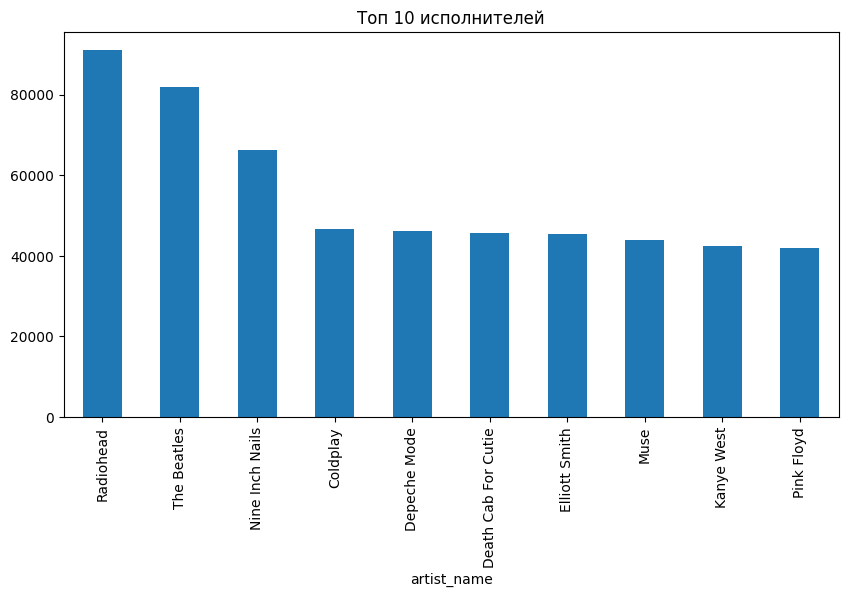

In [3]:
import pandas as pd
import pickle

import matplotlib
from matplotlib import pyplot as plt

with open('../data/dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)
df_train = dataset["train"].to_pandas()

print(f"Записей: {len(df_train):,}")
print(f"Пользователей: {df_train['user_id'].nunique():,}")
print(f"Исполнителей: {df_train['artist_name'].nunique():,}")

top_artists = df_train['artist_name'].value_counts().head(10)
print("\nТоп 10 исполнителей:")
print(top_artists)

plt.figure(figsize=(10, 5))
top_artists.plot(kind='bar')
plt.title('Топ 10 исполнителей')
plt.show()

In [4]:
# Минимальная и максимальная дата
print(f"Первая запись: {df_train['timestamp'].min()}")
print(f"Последняя запись: {df_train['timestamp'].max()}")
print(f"Период: {(df_train['timestamp'].max() - df_train['timestamp'].min()).days} дней")

Первая запись: 2005-02-14 00:00:07
Последняя запись: 2013-09-29 18:32:04
Период: 3149 дней


In [5]:
# Добавляем месяц
df_train['month'] = df_train['timestamp'].dt.to_period('M')

# Количество записей по месяцам
monthly_counts = df_train.groupby('month').size()
print("Записей по месяцам:")
print(monthly_counts)

Записей по месяцам:
month
2005-02     17492
2005-03     35228
2005-04     50843
2005-05     47777
2005-06     60875
2005-07     63886
2005-08     76780
2005-09     83113
2005-10    100337
2005-11    100589
2005-12    131428
2006-01    160808
2006-02    166438
2006-03    216894
2006-04    224932
2006-05    251218
2006-06    247335
2006-07    259291
2006-08    277572
2006-09    267418
2006-10    281335
2006-11    306340
2006-12    333867
2007-01    335855
2007-02    321509
2007-03    311733
2007-04    310563
2007-05    331053
2007-06    286474
2007-07    289286
2007-08    298610
2007-09    311483
2007-10    332093
2007-11    337992
2007-12    326935
2008-01    332371
2008-02    299607
2008-03    331848
2008-04    315801
2008-05    344108
2008-06    343068
2008-07    344638
2008-08    332543
2008-09    356801
2008-10    358974
2008-11    355880
2008-12    355792
2009-01    409429
2009-02    386741
2009-03    427180
2009-04    382896
2009-05     93335
2009-06     39407
2010-08         1
20

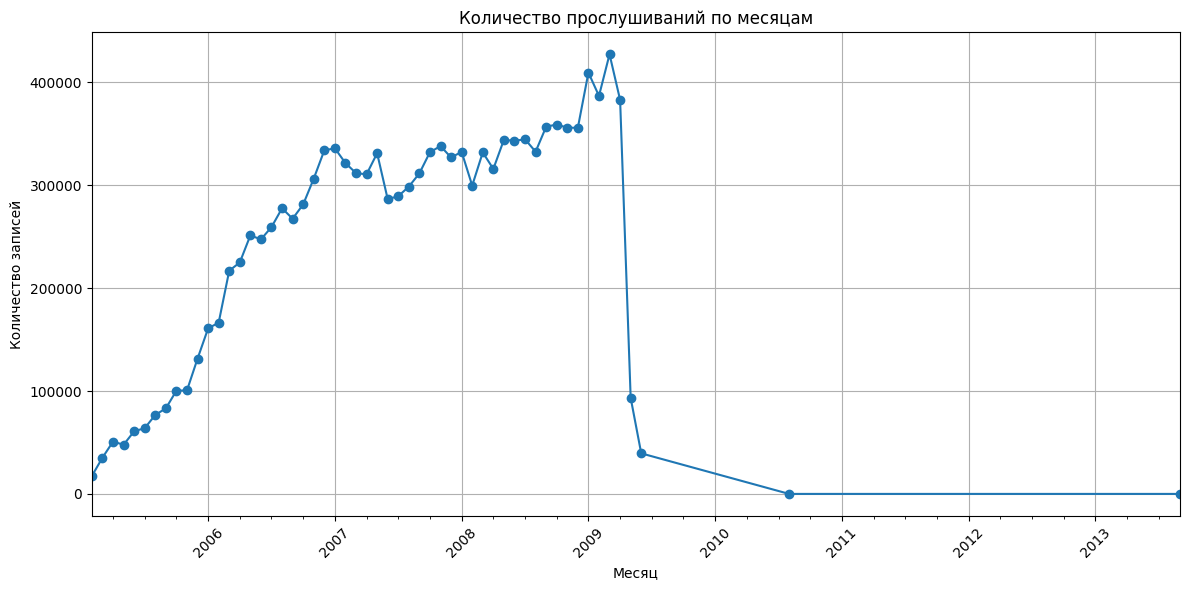

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o')
plt.title('Количество прослушиваний по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество записей')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Топ-10 треков за всё время:
1. The Postal Service — Such Great Heights (3,349 прослушиваний)
2. Radiohead — Karma Police (2,936 прослушиваний)
3. Death Cab For Cutie — Soul Meets Body (2,904 прослушиваний)
4. Boy Division — Love Will Tear Us Apart (2,680 прослушиваний)
5. Kanye West — Love Lockdown (2,651 прослушиваний)
6. The Knife — Heartbeats (2,612 прослушиваний)
7. The Killers — When You Were Young (2,564 прослушиваний)
8. Massive Attack — Teardrop (2,534 прослушиваний)
9. Interpol — Evil (2,521 прослушиваний)
10. Britney Spears — Gimme More (2,506 прослушиваний)


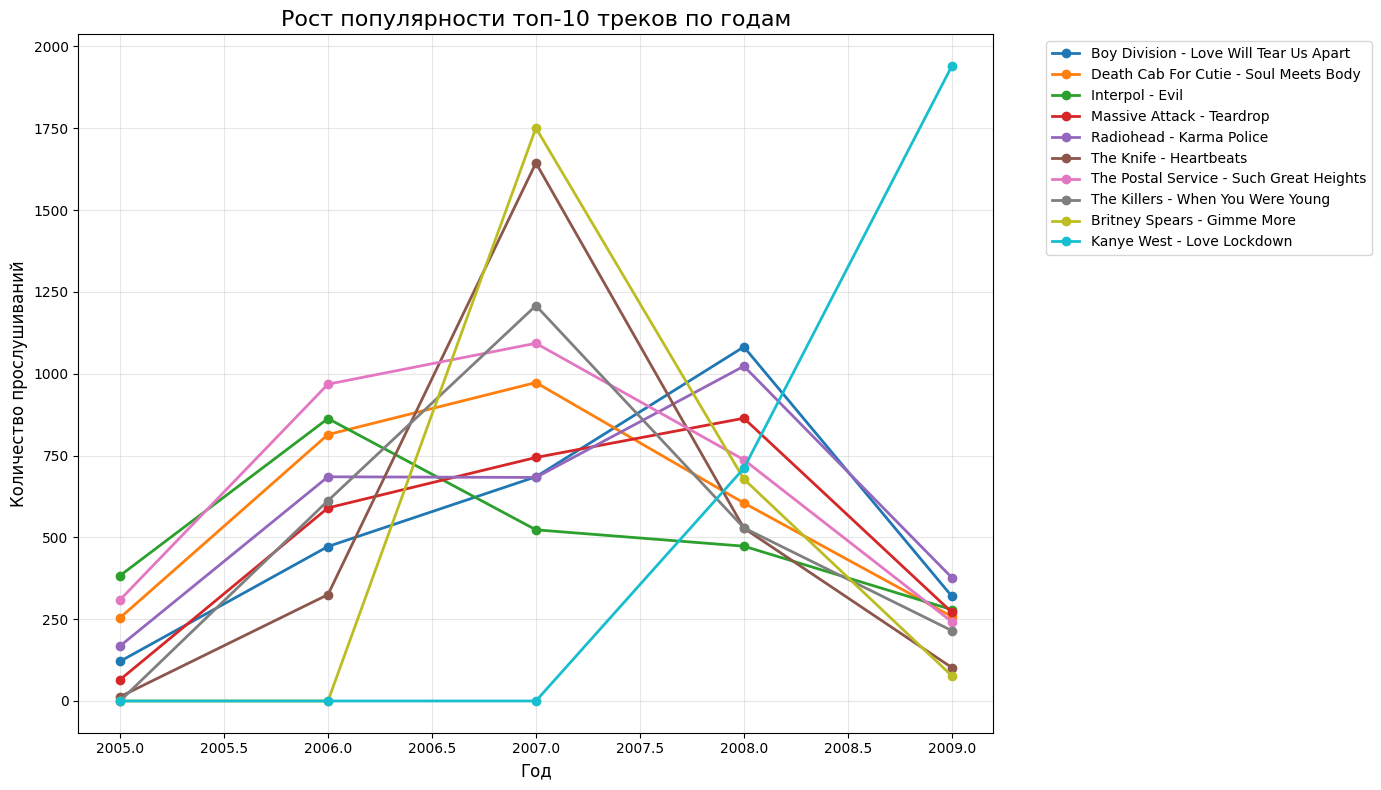

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Убедимся, что timestamp в правильном формате
df_train['year'] = df_train['timestamp'].dt.year

# Топ-10 самых популярных треков за всё время
top_tracks_all = df_train.groupby(['artist_name', 'track_name']).size().sort_values(ascending=False).head(10)
top_tracks_list = top_tracks_all.index.tolist()

print("Топ-10 треков за всё время:")
for i, (artist, track) in enumerate(top_tracks_list, 1):
    count = top_tracks_all[(artist, track)]
    print(f"{i}. {artist} — {track} ({count:,} прослушиваний)")

# Фильтруем данные только по этим трекам
df_top_tracks = df_train[df_train.set_index(['artist_name', 'track_name']).index.isin(top_tracks_list)]

# Группируем по году и треку
yearly_trend = df_top_tracks.groupby(['year', 'artist_name', 'track_name']).size().unstack(level=['artist_name', 'track_name']).fillna(0)

# Переименовываем колонки для красивого отображения
yearly_trend.columns = [f"{artist} - {track}" for artist, track in yearly_trend.columns]

# График
plt.figure(figsize=(14, 8))
for column in yearly_trend.columns:
    plt.plot(yearly_trend.index, yearly_trend[column], marker='o', label=column, linewidth=2)

plt.title('Рост популярности топ-10 треков по годам', fontsize=16)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество прослушиваний', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# Загрузка данных
with open('../data/dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

df = dataset["train"].to_pandas()
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Общая статистика
total_users = df['user_id'].nunique()
print(f"Всего пользователей: {total_users:,}")
print(f"Всего записей: {len(df):,}")
print(f"В среднем на пользователя: {len(df)/total_users:.1f} записей")

Всего пользователей: 794
Всего записей: 13,365,803
В среднем на пользователя: 16833.5 записей


In [11]:
# Функция для подсчёта пользователей в неделе
def get_weekly_coverage(df, week_start):
    week_end = pd.to_datetime(week_start) + pd.Timedelta(days=6)
    df_week = df[(df['timestamp'] >= week_start) & (df['timestamp'] <= week_end)]
    
    return {
        'week': week_start,
        'users': df_week['user_id'].nunique(),
        'records': len(df_week),
        'active_users_pct': df_week['user_id'].nunique() / total_users * 100
    }

# Проверяем несколько недель
weeks_to_check = ['2006-01-01', '2006-02-01', '2006-03-01', '2006-06-01', '2006-09-01', '2006-12-01']

coverage_data = []
for week in weeks_to_check:
    cov = get_weekly_coverage(df, week)
    coverage_data.append(cov)
    print(f"{week}: {cov['users']} пользователей ({cov['active_users_pct']:.1f}% от всех)")

2006-01-01: 145 пользователей (18.3% от всех)
2006-02-01: 172 пользователей (21.7% от всех)
2006-03-01: 189 пользователей (23.8% от всех)
2006-06-01: 261 пользователей (32.9% от всех)
2006-09-01: 302 пользователей (38.0% от всех)
2006-12-01: 328 пользователей (41.3% от всех)
